In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("heart.csv")
print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)
print("\nInfo:\n")
print(df.info())
print("\nSummary:\n", df.describe())

missing_vals = df.isnull().sum()
dup_vals = df.duplicated().sum()
print("\nMissing values:\n", missing_vals)
print("\nDuplicate rows:", dup_vals)

df = df.drop_duplicates()
df = df.dropna()
print("\nAfter cleaning, shape:", df.shape)

First 5 rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Shape: (1025, 14)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64 

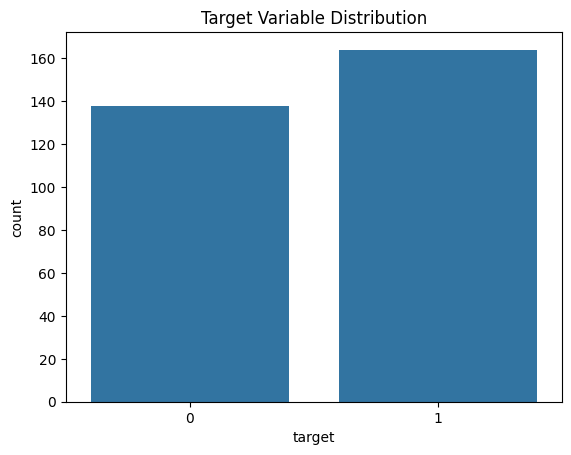


Target Distribution:
 target
1    164
0    138
Name: count, dtype: int64

Dataset Balanced?: Yes


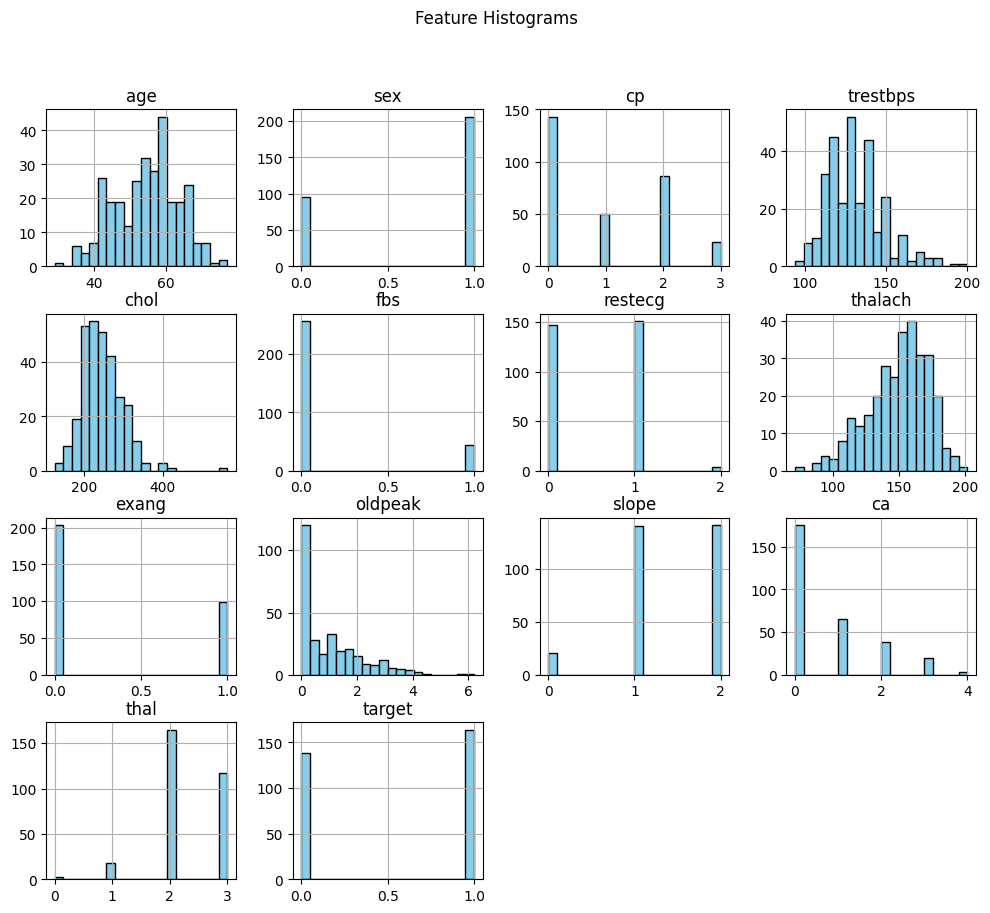

In [5]:
sns.countplot(x='target', data=df)
plt.title("Target Variable Distribution")
plt.show()

target_counts = df['target'].value_counts()
print("\nTarget Distribution:\n", target_counts)
print("\nDataset Balanced?:", "Yes" if abs(target_counts[0] - target_counts[1]) < 0.1 * len(df) else "No")

df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Histograms")
plt.show()

In [6]:
y = df['target']
X = df.drop('target', axis=1)

# Perform EDA
# Ans: The dataset shows no missing or categorical values. Hence, no encoding or imputation required.

# Split 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Further split training into 70% train, 30% validation
x_train_final, x_val, y_train_final, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=0)

print("\nTrain:", x_train_final.shape, "Validation:", x_val.shape, "Test:", x_test.shape)

# Why validation set?
# Ans: Validation set helps tune model hyperparameters and prevent overfitting before testing.



Train: (168, 13) Validation: (73, 13) Test: (61, 13)


In [7]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_final)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Why scaling?
# Ans: Scaling ensures all features contribute equally to distance-based and ensemble models.


In [13]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(x_train_scaled, y_train_final)
print("\nRandom Forest Train Acc:", rf_model.score(x_train_scaled, y_train_final) * 100)
print("Random Forest Test Acc:", rf_model.score(x_test_scaled, y_test) * 100)

# AdaBoost
ada_model = AdaBoostClassifier(algorithm='SAMME', n_estimators=50, random_state=0)
ada_model.fit(x_train_scaled, y_train_final)
print("\nAdaBoost Train Acc:", ada_model.score(x_train_scaled, y_train_final) * 100)
print("AdaBoost Test Acc:", ada_model.score(x_test_scaled, y_test) * 100)

# XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=0)
xgb_model.fit(x_train_scaled, y_train_final)
print("\nXGBoost Train Acc:", xgb_model.score(x_train_scaled, y_train_final) * 100)
print("XGBoost Test Acc:", xgb_model.score(x_test_scaled, y_test) * 100)

# Comparison
results = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost', 'XGBoost'],
    'Train Accuracy (%)': [
        rf_model.score(x_train_scaled, y_train_final) * 100,
        ada_model.score(x_train_scaled, y_train_final) * 100,
        xgb_model.score(x_train_scaled, y_train_final) * 100,
    ],
    'Test Accuracy (%)': [
        rf_model.score(x_test_scaled, y_test) * 100,
        ada_model.score(x_test_scaled, y_test) * 100,
        xgb_model.score(x_test_scaled, y_test) * 100,
    ]
})
print("\nModel Accuracy Comparison:\n", results)



Random Forest Train Acc: 100.0
Random Forest Test Acc: 81.9672131147541

AdaBoost Train Acc: 91.07142857142857
AdaBoost Test Acc: 75.40983606557377

XGBoost Train Acc: 100.0
XGBoost Test Acc: 78.68852459016394

Model Accuracy Comparison:
            Model  Train Accuracy (%)  Test Accuracy (%)
0  Random Forest          100.000000          81.967213
1       AdaBoost           91.071429          75.409836
2        XGBoost          100.000000          78.688525
